In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dtwpair import SlidingWindowDtwPair
from dtwpair.utils.dtw_distance import SquaredDtwDistance
import yfinance as yf

In [3]:
def make_stock_plots(ts_x: np.ndarray, ts_y: np.ndarray, 
                     start_idx_sub_x: int, start_idx_sub_y: int,
                     x_window_size: int, y_window_size: int, 
                     title_x: str, title_y: str,
                     ts_x_name: str, ts_y_name: str):    
  """
  Make stock plots.
  Parameters
  ----------
  ts_x : np.ndarray
      First time series to be plotted.
  ts_y : np.ndarray
      Second time series to be plotted.
  start_idx_sub_x : int
      Starting index of subsequence from the first time series.
  start_idx_sub_y : int
      Starting index of subsequence from the second time series.
  x_window_size : int
      Window size of subsequences from the first time series.
  y_window_size : int
      Window size of subsequences from the second time series.
  title_x : str
      Title of the first plot.
  title_y : str
      Title of the second plot.
  ts_x_name : str
      Name of the first time series.
  ts_y_name : str
      Name of the second time series.
  """

  fig, ax = plt.subplots(2, 1, figsize=(4*8/5, 4*8/5))

  upper_y_axis = max(ts_x.max(), ts_y.max())
  lower_y_axis = min(ts_x.min(), ts_y.min())
  rng = upper_y_axis - lower_y_axis
  buffer = rng * 0.1

  ax[0].plot(ts_x, label=ts_x_name, linewidth=1)
  ax[0].plot(np.arange(start_idx_sub_x, start_idx_sub_x + x_window_size), ts_x[start_idx_sub_x: start_idx_sub_x + x_window_size], label='Detected Subsequence', linewidth=3)
  ax[0].legend(loc='lower right')
  ax[0].set_title(title_x, fontsize=16)
  ax[0].set_xlabel('time (trading day)', fontsize=14)
  ax[0].set_ylabel('z-normalized price', fontsize=14)
  ax[0].set_ylim(lower_y_axis - buffer, upper_y_axis + buffer)

  ax[1].plot(ts_y, label=ts_y_name, linewidth=1)
  ax[1].plot(np.arange(start_idx_sub_y, start_idx_sub_y + y_window_size), ts_y[start_idx_sub_y: start_idx_sub_y + y_window_size], label='Detected Subsequence', linewidth=3)
  ax[1].legend(loc='lower right')
  ax[1].set_title(title_y, fontsize=16)
  ax[1].set_xlabel('time (trading day)', fontsize=14)
  ax[1].set_ylabel('z-normalized price', fontsize=14)
  ax[1].set_ylim(lower_y_axis - buffer, upper_y_axis + buffer)

  plt.tight_layout()
  plt.show()

In [4]:
stock_prices = yf.download(['NVDA', 'VSH', 'TSN'], start='2020-01-01', end='2021-01-01')['Close']
normalized_stock_prices = (stock_prices - stock_prices.mean()) / stock_prices.std()

NVDA = normalized_stock_prices['NVDA'].to_numpy()
VSH = normalized_stock_prices['VSH'].to_numpy()
TSN = normalized_stock_prices['TSN'].to_numpy()

dtwp = SlidingWindowDtwPair(dtw_distance=SquaredDtwDistance(), verbose=False)
x_window_size = 90
y_window_size = 90

res_NVDA_VSH, min_dtw_NVDA_VSH = dtwp.subsequence_nearest_neighbour(NVDA, VSH, x_window_size, y_window_size, allow_temporal_shift=90)
res_NVDA_TSN, min_dtw_NVDA_TSN = dtwp.subsequence_nearest_neighbour(NVDA, TSN, x_window_size, y_window_size, allow_temporal_shift=90)


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  3 of 3 completed


In [5]:
start_tf = 0
range_tf = len(normalized_stock_prices['NVDA'])

start_date = normalized_stock_prices['NVDA'].index[start_tf].strftime('%d %b %Y')
end_date = normalized_stock_prices['NVDA'].index[start_tf + range_tf - 1].strftime('%d %b %Y')

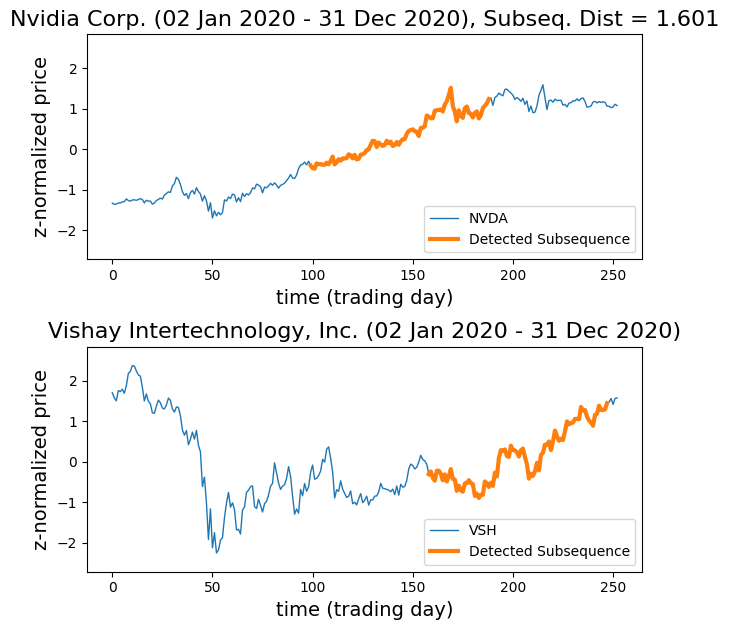

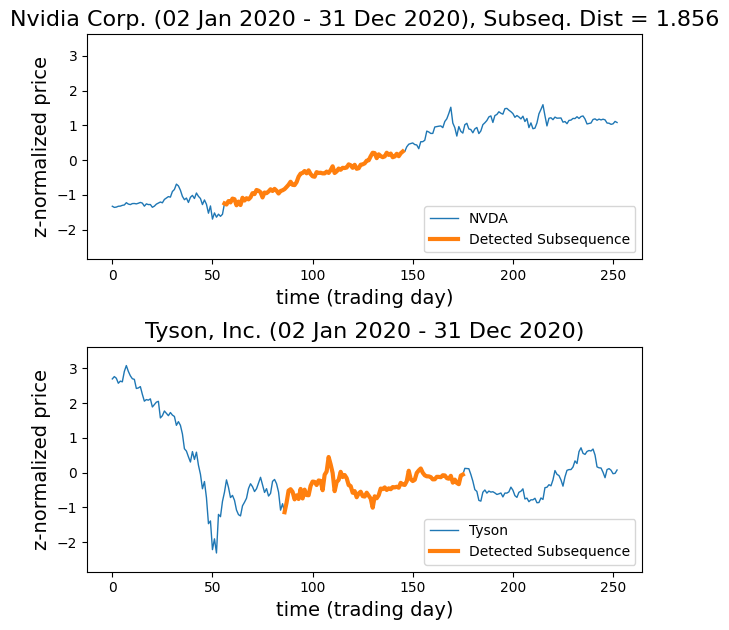

In [6]:
make_stock_plots(NVDA[start_tf: start_tf + range_tf], VSH[start_tf: start_tf + range_tf], \
                res_NVDA_VSH[0][0] - start_tf, res_NVDA_VSH[0][1] - start_tf, \
                x_window_size, y_window_size, \
                f'Nvidia Corp. ({start_date} - {end_date}), Subseq. Dist = {min_dtw_NVDA_VSH[0]:.3f}', \
                f'Vishay Intertechnology, Inc. ({start_date} - {end_date})', \
                'NVDA', 'VSH')    

make_stock_plots(NVDA[start_tf: start_tf + range_tf], TSN[start_tf: start_tf + range_tf], \
                res_NVDA_TSN[0][0] - start_tf, res_NVDA_TSN[0][1] - start_tf, \
                x_window_size, y_window_size, \
                f'Nvidia Corp. ({start_date} - {end_date}), Subseq. Dist = {min_dtw_NVDA_TSN[0]:.3f}', \
                f'Tyson, Inc. ({start_date} - {end_date})', \
                'NVDA', 'Tyson')    